# 7.6.1 前向后向与未来信息

## 学习目标与先修知识

从联合路径推导有限状态（state）平滑，并保持在线和离线的信息边界。

先修：7.2的HMM前向递推与路径联合分布（distribution）。 [本篇学习次序](../README.md)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

细胞先出现模糊标记，后来出现很明确的恢复标记。后面的证据能否帮助解释先前状态？可以，但所得结论与当时实时可用的认识不同。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"]

## 初步实验

In [2]:
print('预测：y[0:t]之前；滤波：截至当前；平滑：允许当前之后。')

预测：y[0:t]之前；滤波：截至当前；平滑：允许当前之后。


## 模型假设

同一有限状态模型（model）、同一观测（observation）记录，缺测机制仍外生。平滑（smoothing）是离线状态重建，不把未来读数放进实时预测或控制。各观测前缀证据正；遇到零证据应先处理模型不支持事件（event）。

## 数学解释与推导

已有前向滤波 $\alpha_t(i)=p(z_t=i\mid y_{0:t})$。定义后向信息
$$\beta_t(i)=p(y_{t+1:T-1}\mid z_t=i),\quad\beta_{T-1}(i)=1.$$
对下一隐藏状态求和得到
$$\beta_t(i)=\sum_jT_{ij}\ell_{t+1}(j)\beta_{t+1}(j).$$
过去与未来在给定当前状态后条件独立（conditional independence），因此平滑后验（posterior）
$$\gamma_t(i)=\frac{\alpha_t(i)\beta_t(i)}{\sum_j\alpha_t(j)\beta_t(j)}.$$
这是前向—后向算法（forward–backward algorithm）。每次对beta乘同一正标量不改gamma，可归一化避免长乘积下溢。当前似然（likelihood）已经进入alpha，后向应从t+1开始，避免重复使用当前观测。末端beta=1，所以最后的平滑与滤波完全相同。

## 核心实现

下面按推导写出计算步骤；函数的输入（input）只包含模型与当时可用的信息。

In [3]:
def hmm_filter(initial, transition, likelihoods):
    posterior = np.array(initial, float)
    transition = np.array(transition, float)
    result = dict(predictions=[], posteriors=[], evidence=[], status='ok')
    for t, likelihood in enumerate(likelihoods):
        prediction = posterior if t == 0 else posterior @ transition
        likelihood = np.ones(len(initial)) if likelihood is None else np.array(likelihood, float)
        mass = prediction * likelihood
        evidence = float(mass.sum())
        result['predictions'].append(prediction.tolist())
        result['evidence'].append(evidence)
        if evidence <= 0:
            result['status'] = 'impossible'
            return result
        posterior = mass / evidence
        result['posteriors'].append(posterior.tolist())
    return result


def hmm_smooth(initial, transition, likelihoods):
    filtered = hmm_filter(initial, transition, likelihoods)
    if filtered['status'] != 'ok':
        raise ValueError('零证据序列不能条件化')
    T, n = len(likelihoods), len(initial)
    backward = np.ones(n)
    smoothed = [None] * T
    for t in range(T-1, -1, -1):
        mass = np.array(filtered['posteriors'][t]) * backward
        smoothed[t] = (mass / mass.sum()).tolist()
        if t > 0:
            emission = np.ones(n) if likelihoods[t] is None else np.array(likelihoods[t])
            backward = np.array(transition) @ (emission * backward)
            backward /= backward.sum()
    return smoothed

## 对照实验

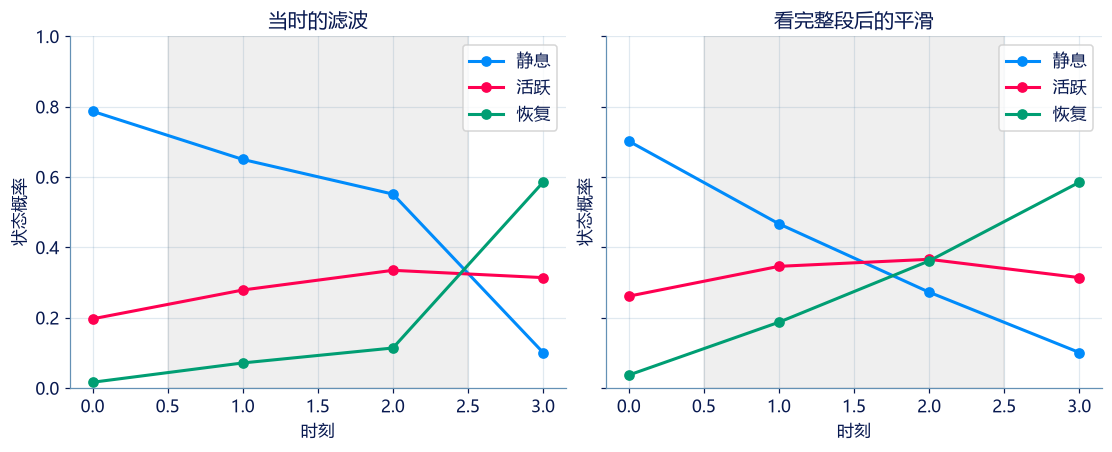

In [4]:
initial=[.6,.3,.1];transition=[[.8,.15,.05],[.1,.8,.1],[.05,.2,.75]];likelihoods=[[.8,.4,.1],None,None,[.05,.2,.95]]
filtered=hmm_filter(initial,transition,likelihoods);smoothed=hmm_smooth(initial,transition,likelihoods)
fig,axes=plt.subplots(1,2,figsize=(10,4),sharey=True)
for ax,values,title in [(axes[0],filtered['posteriors'],'当时的滤波'),(axes[1],smoothed,'看完整段后的平滑')]:
    for i,label in enumerate(['静息','活跃','恢复']):ax.plot(np.array(values)[:,i],marker='o',label=label)
    ax.axvspan(.5,2.5,color='gray',alpha=.12);ax.set(xlabel='时刻',ylabel='状态概率',ylim=(0,1),title=title);ax.legend()
plt.show()

### 独立核验与边界

In [5]:
from itertools import product
joint=np.zeros((len(likelihoods),3));evidence=0.
for path in product(range(3),repeat=len(likelihoods)):
    weight=initial[path[0]]
    for t,state in enumerate(path):
        if likelihoods[t] is not None:weight*=likelihoods[t][state]
        if t:weight*=transition[path[t-1]][state]
    evidence+=weight
    for t,state in enumerate(path):joint[t,state]+=weight
np.testing.assert_allclose(joint/evidence,smoothed,atol=1e-12)
np.testing.assert_allclose(smoothed[-1],filtered['posteriors'][-1])
np.testing.assert_allclose(hmm_smooth(initial,transition,[None])[0],initial)
assert hmm_smooth(initial,transition,[])==[]
with np.errstate(all='raise'):
    assert hmm_smooth([1,0],[[0,1],[0,1]],[[1,0]])==[[1.,0.]]
print('全路径边缘、末端、单时刻和空序列检查通过。')

全路径边缘、末端、单时刻和空序列检查通过。


## 结果解释

缺测段没有读数，但后来的恢复标记通过状态转移关联改变对过去的判断。平滑曲线更“有把握”不表示过去的观察者当时就知道这些信息；在评价在线方法时混用两条曲线会造成未来信息泄漏。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：把未来读数传回过去

已知有限状态（state）HMM，计算全部观测（observation）条件下每个时刻的平滑后验（posterior）。

**函数与代码模板**

```python
def solve(
    initial: list[float],
    transition: list[list[float]],
    likelihoods: list[list[float] | None],
) -> list[list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `initial` | `list[float]` | 时刻0先验（prior）。 | 概率 |
| `transition` | `list[list[float]]` | 行随机转移矩阵（transition matrix）。 | 概率 |
| `likelihoods` | <code>list[list[float] &#124; None]</code> | 每时刻的似然（likelihood），None为缺测。 | 无量纲 |

**返回值**

直接返回 smoothed（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `smoothed` | `list[list[float]]` | p(z[t] &#124; y[0:T])，按时刻排列。 | 概率 |

**计算规则**

先做前向滤波，设末端beta=1。gamma[t]与alpha[t]*beta[t]成比例；beta[t]=T@(likelihood[t+1]*beta[t+1])，可每步缩放。缺测似然全1。空序列返回空列表。

**约束与边界**

- 2—3状态，0—12时刻；所有观测前缀证据严格正。
- 初始及转移行归一化，似然在[0,1]。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| initial | 时刻0先验（prior）。 | [0.6, 0.4] | 概率 |
| transition | 行随机转移矩阵（transition matrix）。 | [[0.8, 0.2], [0.1, 0.9]] | 概率 |
| likelihoods | 每时刻的似然（likelihood），None为缺测。 | [[0.2, 0.8], [0.7, 0.3]] | 无量纲 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
initial = [0.6, 0.4]
transition = [[0.8, 0.2], [0.1, 0.9]]
likelihoods = [[0.2, 0.8], [0.7, 0.3]]

result = solve(initial, transition, likelihoods)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| smoothed | p(z[t] | y[0:T])，按时刻排列。 | [[0.4061135371179039, 0.5938864628820961], [0.4890829694323144, 0.5109170305676857]] | 概率 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[0.4061135371179039, 0.5938864628820961],
                   [0.4890829694323144, 0.5109170305676857]]
```

**样例解释**

两步观测时，第一步平滑还利用第二个读数；最后一步平滑必须等于最后一步滤波。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：把未来读数传回过去](http://127.0.0.1:8000/chapters/07-06-%E5%B9%B3%E6%BB%91%E4%B8%8E%E7%BC%BA%E6%B5%8B%E5%A4%84%E7%90%86/practice/?question=p07-hmm-smoothing)

### 第 2 题 · 多项选择题：三种估计分别知道什么

在时刻t讨论状态（state）x[t]。哪些对应关系正确？

- **A.** 预测只使用t之前的观测（observation）。
- **B.** 滤波使用截至t的观测。
- **C.** 平滑允许使用t之后的观测。
- **D.** 平滑后再删掉未来读数就恢复实时可用性。

[作答：三种估计分别知道什么](http://127.0.0.1:8000/chapters/07-06-%E5%B9%B3%E6%BB%91%E4%B8%8E%E7%BC%BA%E6%B5%8B%E5%A4%84%E7%90%86/practice/?question=p07-three-information-sets)

### 第 3 题 · 单项选择题：后向信息从哪一步开始

beta[t]=p(y[t+1:T] | z[t])。哪项递推正确？

- **A.** beta[t]=T@(likelihood[t]*beta[t+1])。
- **B.** beta[t]=T@(likelihood[t+1]*beta[t+1])。
- **C.** beta[t]=alpha[t]。
- **D.** beta[T]必须等于最后一个似然（likelihood）。

[作答：后向信息从哪一步开始](http://127.0.0.1:8000/chapters/07-06-%E5%B9%B3%E6%BB%91%E4%B8%8E%E7%BC%BA%E6%B5%8B%E5%A4%84%E7%90%86/practice/?question=p07-backward-index)

### 第 4 题 · 单项选择题：平滑更好能推实时更好吗

离线平滑的过去状态（state）RMSE低于滤波。哪项有依据？

- **A.** 可直接宣称在线控制会同样改善。
- **B.** 说明更多未来信息在该离线重建实验有帮助。
- **C.** 滤波算法必定实现错误。
- **D.** 未来信息已成为过去真实可获得的信息。

[作答：平滑更好能推实时更好吗](http://127.0.0.1:8000/chapters/07-06-%E5%B9%B3%E6%BB%91%E4%B8%8E%E7%BC%BA%E6%B5%8B%E5%A4%84%E7%90%86/practice/?question=p07-offline-online)

### 延伸阅读

R26，第12章Bayes平滑和有限状态前向—后向。 [Särkkä 与 Svensson，《Bayesian Filtering and Smoothing》第二版，2023](https://users.aalto.fi/~ssarkka/pub/bfs_book_2023_online.pdf)。本节公式、实现和核验可独立阅读；参考资料用于进一步学习。

[概念探索与交互](http://127.0.0.1:8000/chapters/07-06-平滑与缺测处理/explore/) · [本篇目录](../README.md)